# Study on effect of noise on state transfer (Fidelity)

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as lin
import math as math
import sympy as sym
import cmath as cmath

In [2]:
pi = np.pi

In [3]:
def computational_basis(n, k):
    v = np.matrix([0]*n).transpose()
    v[k] = 1
    return(v)

In [4]:
def ket_vector(n, v):
    ket = [0] * n
    ket[v] = 1
    return np.matrix(ket).transpose()

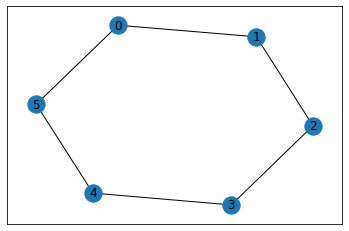

In [5]:
G = nx.cycle_graph(6)
nx.draw_networkx(G)

In [6]:
s = 0
r = 1

In [7]:
n = G.order()
n

6

In [8]:
m = G.number_of_edges()
m

6

In [9]:
total_degree = 2 * m
total_degree

12

In [10]:
def initial_state(G, s):
    d = G.degree(s)
    H = G.to_directed()
    E = list(H.edges())
    m = len(E)
    z = np.matrix(np.zeros((m, 1)))
    out_edges_of_s = H.out_edges(s)
    for e in out_edges_of_s:
        i = E.index(e)
        z = z + computational_basis(m, i)
    return(z/math.sqrt(d))

In [11]:
def target_state(G, r):
    d = G.degree(r)
    H = G.to_directed()
    E = list(H.edges())
    m = len(E)
    z = np.matrix(np.zeros((m, 1)))
    out_edges_of_r = H.out_edges(r)
    for e in out_edges_of_r:
        i = E.index(e)
        z = z + computational_basis(m, i)
    return(z/math.sqrt(d))

In [12]:
phi = target_state(G, r)
phi

matrix([[0.        ],
        [0.        ],
        [0.70710678],
        [0.70710678],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]])

In [13]:
psi = initial_state(G, s)
psi

matrix([[0.70710678],
        [0.70710678],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]])

##### Initial state density matrix

In [14]:
IS = psi * psi.transpose()
IS

matrix([[0.5, 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0.5, 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ]])

In [15]:
def Grover(G, v):
    n = G.order()
    d = G.degree(v)
    psi = np.matrix(np.zeros((d, 1)))
    for i in range(d):
        psi = psi + computational_basis(d, i)
    psi = psi/math.sqrt(d)
    I_d = np.matrix(np.eye(d))
    G = 2 * psi * psi.transpose() - I_d
    return(np.matrix(G))

In [16]:
def coin(G, s, r):
    L = []
    for v in G.nodes():
        if v == s or v == r:
            L.append(-1 * Grover(G, v))
        else:
            L.append(Grover(G, v))
    return(np.matrix(lin.block_diag(*L)))

In [17]:
def shift_operator(G):
    m = G.number_of_edges()
    S = np.zeros((2*m , 2*m))
    V = list(G.nodes())
    Directed_edges = []
    for v in V:
        Temp = np.sort(list(G.neighbors(v)))
        for u in Temp:
            Directed_edges.append((v,u))
    for e in Directed_edges:
        i = Directed_edges.index(e)
        f = (e[1], e[0])
        j = Directed_edges.index(f)
        S[i][j] = 1
    return(np.matrix(S))

In [18]:
def evol_operator(G, s, r):
    S = shift_operator(G)
    C = coin(G, s , r)
    T = S * C
    return(np.matrix(T))

In [19]:
U = evol_operator(G, s, r)

## State transfer without noise

### Evolution of quantum walk

$$ |\phi(t)> = U^t|\phi(0)>.$$

In [20]:
T = 100

In [21]:
def evolve_vector_t_step(U, psi, t):
    return (U**t)*psi

##### Fidelity for state vectors

Given state vectors $|a>$ and $|b>$ the fidelity is given by
$$F(a, b) = |<a | b >|^2.$$

In [22]:
def fidelity_with_vectors(a, b):
    f = abs(a.transpose() * b)**2
    return(f.item())

In [23]:
a = phi
F_without_noise = []
for t in np.arange(0, T+1):
    b = evolve_vector_t_step(U, psi, t)
    f = fidelity_with_vectors(a, b)
    F_without_noise.append(f)

In [24]:
T_axis = list(range(len(F_without_noise)))

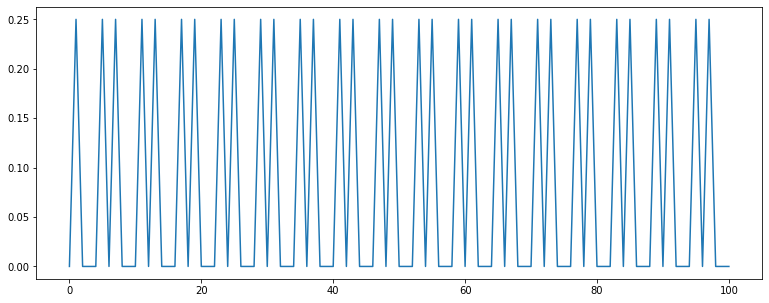

In [25]:
plt.figure(figsize = (13, 5))
plt.plot(T_axis, F_without_noise)
plt.show()

## State transfer with noise

## Noise function
$$ 
e^{-\frac{\lambda}{2} \left(t + \frac{1}{\gamma} \left(e^{-\gamma t} - 1\right)\right)} $$


In [26]:
def noise_function(Lambda, gamma, t):
    r = t + (1/gamma) * (cmath.exp(-gamma*t) - 1)
    s = cmath.exp(-(Lambda/2)* r)
    return(s)

/home/monika/.local/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


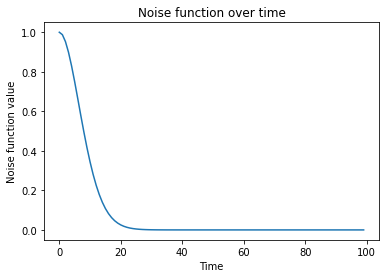

In [27]:
Lambda = 1
gamma = 0.05
noise_function_value = []
for t in range(T):
    noise_function_value.append(noise_function(Lambda, gamma, t))
plt.plot(range(T), noise_function_value)
plt.xlabel('Time')
plt.ylabel('Noise function value')
plt.title('Noise function over time')
plt.show()

##### Weyl operator
 $$U_{u, u} = I_d,$$
$$U_{u, u_0} = \sum_{k = 0}^{d - 1} \exp\left(\frac{2\pi \iota u k}{d}\right) |k> <(k + u_0) mod d|$$


In [28]:
def w_coeff(d, u, k):
    return(cmath.exp((2j * cmath.pi * u * k )/ (d)))

In [29]:
def Weyl(G, u, u_0):
    m = G.number_of_edges()
    z = np.matrix(np.zeros((2 * m, 2 * m)))
    for k in range(2 * m):
        w = w_coeff(2 * m, u, k)
        z = z + w * ket_vector(2 * m, k) * ket_vector(2 * m, (k + u_0) % (2 * m)).transpose()
    return(z)

In [30]:
u = 1
u_0 = 0
W = Weyl(G, u, u_0)
np.around(W*np.conjugate(W).transpose(), 4)

matrix([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
         0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
         0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 1.-0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
         0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
         0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
         0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.-0.j, 0.+0.j, 0.+0.j,
         0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j,
         0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.-0.j,
         0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       

##### Kraus opeartors

In [31]:
def K1(G, Lambda, gamma, t):
    m = G.number_of_edges()
    I = np.matrix(np.eye((2 * m)))
    P = noise_function(Lambda, gamma, t)
    z = np.sqrt((1 + P)/2)*I
    return(z)

In [32]:
def K2(G, Lambda, gamma, t):
    m = G.number_of_edges()
    P = noise_function(Lambda, gamma, t)
    z = np.sqrt((1-P)/2)*Weyl(G, u, u_0)
    return(z)

In [33]:
t = 0
K_1 = K1(G, Lambda, gamma, t)
K_2 = K2(G, Lambda, gamma, t)
np.around(K_1*np.conjugate(K_1).transpose() + K_2*np.conjugate(K_2).transpose(), 4)

matrix([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
         0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
         0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
         0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
         0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
         0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j,
         0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j,
         0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j,
         0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       

### Evolution of quantum walk

$$ \rho(t) = \sum_{j} K_{j}(t) (U^t\rho(0) U^{t\dagger}) K_{j}^{\dagger}(t) $$

In [34]:
def evolve_matrix_t_step(G, Lambda, gamma, t, IS, s, r):
    K_1 = K1(G, Lambda, gamma, t)  
    K_2 = K2(G, Lambda, gamma, t)
    U = evol_operator(G, s, r)
    rho = (U**t) * IS * np.conjugate(U**t).transpose()
    rho_t = K_1 * rho * np.conjugate(K_1).transpose() + K_2 * rho * np.conjugate(K_2).transpose()
    return rho_t

##### Fidelity between two density matrices

$$ F(\rho, \sigma)  =  (Tr(\sqrt{\sqrt{\sigma}\rho\sqrt{\sigma}}))^2 $$

In [35]:
def fidelity(rho, sigma):
    fidelity = np.trace(lin.sqrtm((lin.sqrtm(sigma) * rho * lin.sqrtm(sigma))))
    fidelity = np.abs(fidelity) ** 2
    return fidelity

In [36]:
rho = phi * phi.transpose()
F_with_noise = []
for t in np.arange(0, T+1):
    sigma = np.around(evolve_matrix_t_step(G, Lambda, gamma, t, IS, s, r),10)
    f = fidelity(rho, sigma)
    F_with_noise.append(f)

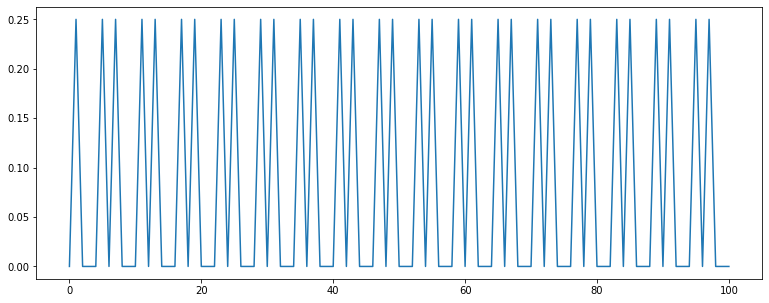

In [37]:
plt.figure(figsize = (13, 5))
plt.plot(T_axis, F_with_noise)
plt.show()

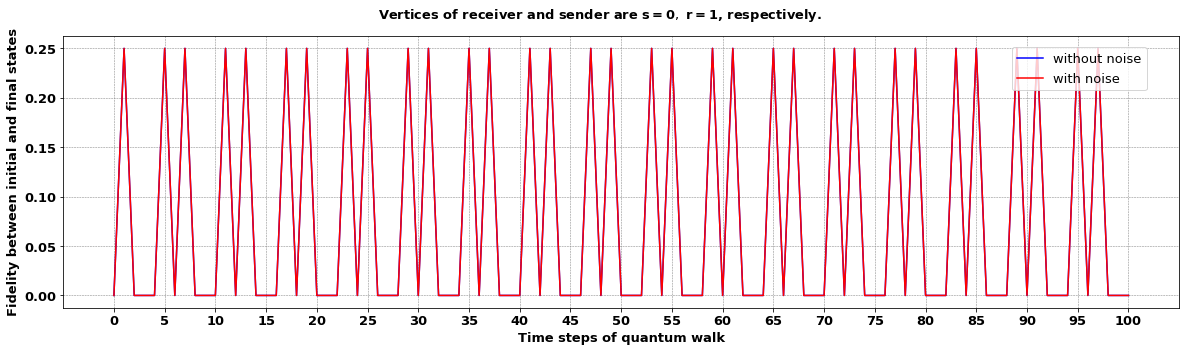

In [38]:
plt.figure(figsize=(20, 5))
plt.grid(True, color='gray', linestyle='--', linewidth=0.5)
plt.plot(T_axis, F_without_noise, label="without noise", color = "blue")
plt.plot(T_axis, F_with_noise, label="with noise", color = "red")
plt.xticks(list(np.arange(0, T+5, 5)), fontsize = 13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')
plt.legend(loc=(0.85, .8), fontsize=13)
plt.text(26, .28, r"Vertices of receiver and sender are $\mathbf{s = " + str(s) + "},\ \mathbf{r = " + str(r) + "}$, respectively.",
fontsize=13,fontweight='bold')
plt.xlabel("Time steps of quantum walk", fontsize=13,fontweight='bold')
plt.ylabel("Fidelity between initial and final states", fontsize=13, fontweight='bold')
plt.show()